Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill up your name and collaborators below:

In [62]:
NAME = "Andre Perez"
UNI  = "avp2141"
COLLABORATORS = "Alexander Speer, aes2376"

# BMEBW4020 Fall 2025 - Project 1 Problem 1 (50 pts)

An electrocardiogram (ECG, also called an EKG) records electrical signals from the heart and is routinely used to quickly detect heart problems and monitor the heart's health.
We will use the methods discussed in class for nonlinear ODE modeling and simulation to implement a simplified model for generating realistic healthy and pathological ECG signals, and will then use phase response analysis to characterize the corresponding limit cycles. This problem is based on the [paper](https://www.nature.com/articles/s41598-019-55448-5).

## Tasks

1. Read the paper, and prove (show your steps) that the model described by equations (2) indeed reduce to the model defined by equations (3) for the initial condition: $x_2(0) = x_6(0)$ and $\dot{x}_2(0) = \dot{x}_6(0)$. (10pt)
2. Simulate the model defined by the set of equations (3) and (4) for two cases (a) Healthy heart: Use $H=3, \alpha_1=-0.024, \alpha_2=0.0216, \alpha_3=-0.0012, \alpha_4=0.12$ (b) Sinus Tachycardia: Use $H=2.848, \alpha_1=0, \alpha_2=-0.1, \alpha_3=0, \alpha_4=0$. For both cases use $C=1.35, \beta = 4$,  initial conditions $x_1=0.0, x_2=0.0, x_3=0.1, x_4=0.0$, and a timestep $dt=10^{-4}s$. (20pt)
3. Use Winfree's method to estimate the Phase Response Curve of the healthy heart ECG signal with respect to (i) $x_1$ (SA node), and (ii) $x_3$ (AV node). (10pt)
4. From the phase response curves obtained in 3, infer the _safest time-interval_ to inject a brief current pulse into the heart (such as during cardioversion) so that it _does not change the timing of the next heartbeat_. You must explain your reasoning. (10pt)

## Bonus (Extra 12.5 pts):
*Bonus points will be counted towards final grades as well (this is worth 5% of final grade bonus)*

Compare your result from Q.4(i) against the SA node plot given in Figure 4(a) of this [paper](https://link.springer.com/content/pdf/10.1114/1.1553455.pdf). Note that you will have to report the PRC in a slightly different way to make this comparison (refer to the paper for details).

## Further reading
*For those interested in how PRCs can be further applied to non-neuroscience biomed settings*

We can also incorporate breathing and how it couples with the heart's rhythm into an ECG model, and non-invasively estimate the joint phase response manifold and phase-coupling functions for this model. Details can be found in this [paper](https://www.nature.com/articles/ncomms3418).

TASK 1

Step 1: Equivariance and the symmetric subspace

Let P be the reflection that swaps the boundary nodes:
P(x1, x2, x3, x4, x5, x6) = (x5, x6, x3, x4, x1, x2).

Because the three-node BVAM discretization with Neumann boundary conditions is left–right symmetric (the boundary nodes are mirror images and the diffusive couplings are identical), the vector field F of system (2) satisfies F(PX) = P F(X) for all states X.

Therefore, the set
S = { X : P X = X } = { x1 = x5, x2 = x6 }
is an invariant subspace: if the system starts in S, the trajectory remains in S for all t.

To show the solution lies in S, we must verify that the given initial condition implies x1(0)=x5(0).

---

Step 2: Using x2_dot(0)=x6_dot(0) to enforce x1(0)=x5(0)

The equations for x2 and x6 (the v variables at the left and right boundaries) have the same form except that x2_dot depends linearly on x1 and x6_dot depends linearly on x5, both with the same coefficient H. Denoting these boundary equations schematically:

x2_dot = f(x1, x2, x3, x4)
x6_dot = f(x5, x6, x3, x4)

Define delta2 = x2 - x6. Then

delta2_dot = x2_dot - x6_dot
= f(x1, x2, x3, x4) - f(x5, x6, x3, x4).

When x2(0) = x6(0), all symmetric terms cancel, leaving

delta2_dot(0) = H * (x1(0) - x5(0)).

But the given condition x2_dot(0) = x6_dot(0) means delta2_dot(0) = 0. Therefore,

0 = H * (x1(0) - x5(0)).

Since H ≠ 0, we conclude that x1(0) = x5(0).

Thus X(0) lies in S.

---

Step 3: Uniqueness implies equality for all time

Let X(t) be the solution of system (2) with the given initial condition, and define Y(t) = P X(t). Because F is P-equivariant, we have

Y_dot(t) = P X_dot(t) = P F(X(t)) = F(P X(t)) = F(Y(t)).

Also Y(0) = P X(0) = X(0), since X(0) ∈ S. By uniqueness of ODE solutions, it follows that Y(t) = X(t) for all t.

Therefore P X(t) = X(t) for all t, which means

x1(t) = x5(t) and x2(t) = x6(t) for all t.

---

Step 4: Reduction to the 4-dimensional model (system 3)

On the invariant subspace S, we can replace x5(t) with x1(t) and x6(t) with x2(t) in all six equations of system (2). This eliminates two redundant equations and leaves a closed system of four equations for (x1, x2, x3, x4).

Those four equations are exactly the model given as system (3).

Hence, under the initial condition x2(0)=x6(0) and x2_dot(0)=x6_dot(0), the dynamics of system (2) reduce to system (3), as required.

In [63]:
# === Mount Drive and point to THIS HW package ===
from google.colab import drive
drive.mount('/content/drive')

import sys, importlib

# If an old copy of compneuro is hanging around in memory, drop it
if 'compneuro' in sys.modules:
    del sys.modules['compneuro']

# TODO: update the path below to the folder for THIS pset
# (for example "hw5" or whatever your instructor used)
hw_path = "/content/drive/MyDrive/CCircuits/project1"
if hw_path not in sys.path:
    sys.path.insert(0, hw_path)

# === Imports ===
%matplotlib inline

import numpy as np
np.random.seed(0)  # fix random seed

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["figure.dpi"] = 100

from collections import OrderedDict

# Core course utilities for this pset
from compneuro.base_model import BaseModel
from compneuro.utils.signal import spike_detect

# (Optional) quick version check / sanity
import numpy, scipy
print("NumPy:", numpy.__version__, "SciPy:", scipy.__version__)

# (Optional) helper to reload compneuro if you edit the files in Drive
import compneuro
importlib.reload(compneuro)

print("HW path:", hw_path)
print("compneuro imported OK.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NumPy: 2.0.2 SciPy: 1.16.3
HW path: /content/drive/MyDrive/CCircuits/project1
compneuro imported OK.


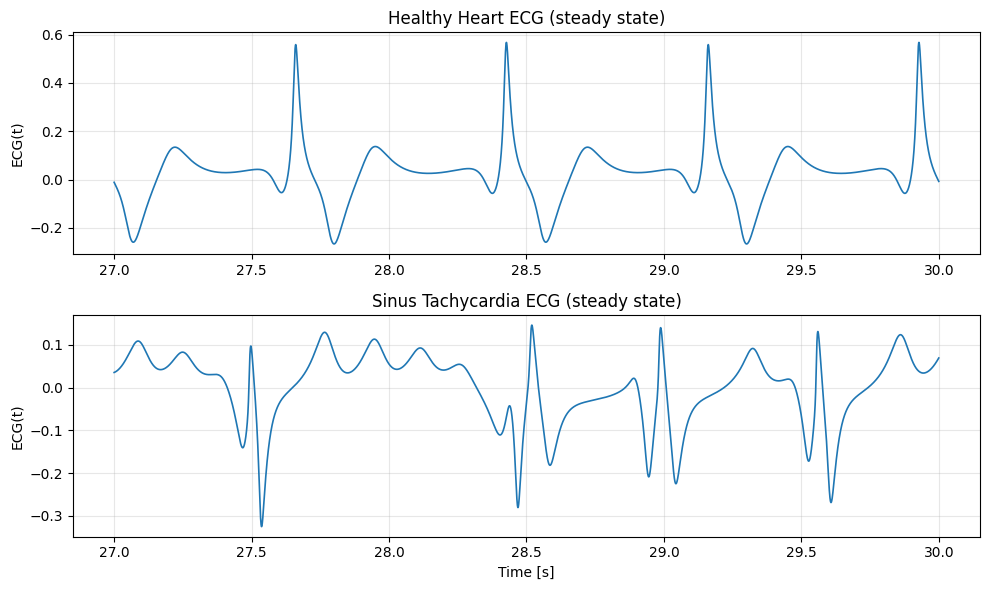

In [64]:
# define ECG model
# you can inherit from BaseModel if you wish to use CompNeuro to simulate your model


# simulate ECG
def simulate_ecg(H, alphas, gamma_t):
    a1, a2, a3, a4 = alphas
    x = x0.copy()
    X = np.empty((n_steps + 1, 4), dtype=float)
    ecg = np.empty(n_steps + 1, dtype=float)

    for k in range(n_steps + 1):
        X[k] = x
        ecg[k] = a1*x[0] + a2*x[1] + a3*x[2] + a4*x[3]
        dx = rhs_core(x, H)
        x += dt * gamma_t * dx
    return X, ecg


# healthy heart parameters
H_healthy = 3.0
alphas_healthy = (-0.024, 0.0216, -0.0012, 0.12)
gamma_healthy = 7.0

X_h, ecg_h = simulate_ecg(H_healthy, alphas_healthy, gamma_healthy)
t_h_win, ecg_h_win = last_window(t, ecg_h, 3.0)


# sinus tachycardia
H_tachy = 2.848
alphas_tachy = (0.0, -0.1, 0.0, 0.0)
gamma_tachy = 14.0   # roughly twice as fast

X_t, ecg_t = simulate_ecg(H_tachy, alphas_tachy, gamma_tachy)
t_t_win, ecg_t_win = last_window(t, ecg_t, 3.0)
ecg_t_win_centered = ecg_t_win - np.mean(ecg_t_win)


# plot both signals
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t_h_win, ecg_h_win, lw=1.2)
plt.title("Healthy Heart ECG (steady state)")
plt.ylabel("ECG(t)")
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t_t_win, ecg_t_win_centered, lw=1.2)
plt.title("Sinus Tachycardia ECG (steady state)")
plt.xlabel("Time [s]")
plt.ylabel("ECG(t)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


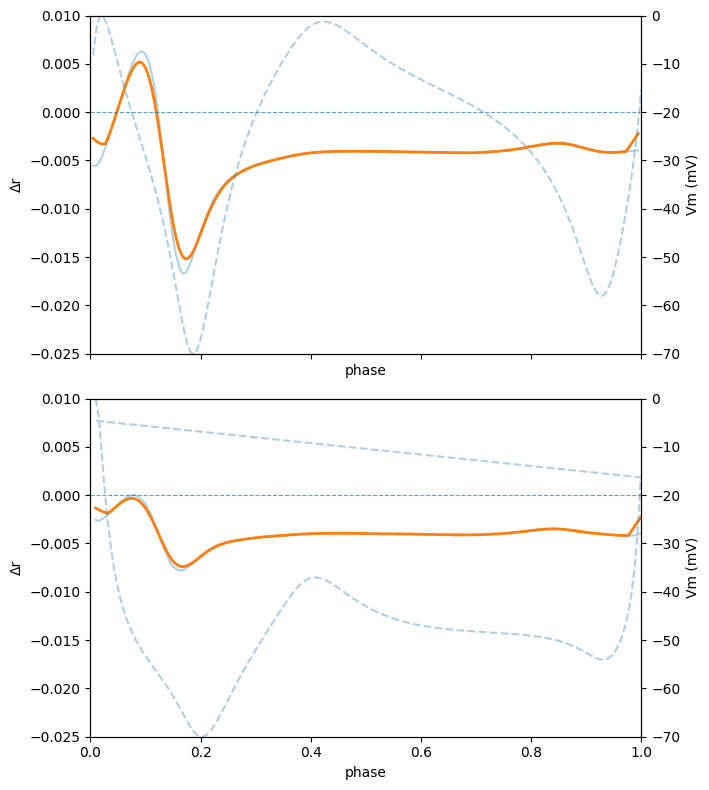

In [65]:
## Compute and plot the PRC of the healthy ECG signal with respect to x_4 (AV node)
## Compute and plot the PRC of the healthy ECG signal with respect to x_2 (SA node)

# r-peak detection (short + simple)
def detect_R_peaks_max(ecg, t_arr, frac=0.90, refractory=0.30):
    ecg = np.asarray(ecg, float)
    emin, emax = float(ecg.min()), float(ecg.max())
    th = emin + frac * (emax - emin)
    peaks_t, last_t = [], -1e9
    for i in range(1, len(ecg)-1):
        if ecg[i-1] < ecg[i] > ecg[i+1] and ecg[i] >= th:
            ti = t_arr[i]
            if (ti - last_t) >= refractory:
                peaks_t.append(ti)
                last_t = ti
    return np.asarray(peaks_t, float)


# winfree prc (minimal comments, same api)
def winfree_prc_localcycle_pulse_upstroke_DEBUG(
    X, ecg, t_arr, which_var,
    I_mag=0.65, pulse_ms=2e-3, n_phases=180,
    H=H_healthy, gamma_t_val=gamma_healthy,
    r_frac=0.90, refractory_frac=0.36,
    typeI_window=(0.94, 1.06), post_guard_ms=0.0025
):
    """Winfree PRC for one state var (x2 or x4)."""
    X = np.asarray(X, float); ecg = np.asarray(ecg, float)
    xvar = X[:, which_var]
    r_all = detect_R_peaks_max(ecg, t_arr, frac=r_frac, refractory=0.30)

    phis_out = np.linspace(0.0, 1.0, n_phases, endpoint=False)
    Tp_over_tau = np.full(n_phases, np.nan, float)
    cell_cycle  = np.full(n_phases, np.nan, float)
    reason_codes = np.full(n_phases, -1, int)
    valid_mask   = np.zeros(n_phases, bool)

    if r_all.size < 4:
        return phis_out, Tp_over_tau, cell_cycle, dict(valid_mask=valid_mask, reason_codes=reason_codes)

    def ecg_from_state(xv):
        return (alphas_healthy[0]*xv[0] + alphas_healthy[1]*xv[1] +
                alphas_healthy[2]*xv[2] + alphas_healthy[3]*xv[3])

    def max_upstroke_time(t0, t1):
        m = (t_arr >= t0) & (t_arr < t1)
        ds = np.gradient(xvar[m], t_arr[m])
        j = int(np.argmax(ds))
        return float(t_arr[m][j])

    pulse_steps = max(1, int(round(pulse_ms / dt)))

    for k, phi_in in enumerate(phis_out):
        t_prev_ref, t_next_ref = r_all[-3], r_all[-2]
        tau_ref = float(t_next_ref - t_prev_ref)
        t_guess = t_prev_ref + phi_in * tau_ref
        j = np.searchsorted(r_all, t_guess)
        if j == 0 or j >= r_all.size:
            continue
        t_prev, t_next = r_all[j-1], r_all[j]
        tau_loc = float(t_next - t_prev)

        # local threshold + injection time
        mloc = (t_arr >= t_prev) & (t_arr <= t_next)
        e_min, e_max = float(ecg[mloc].min()), float(ecg[mloc].max())
        r_th = e_min + r_frac * (e_max - e_min)
        t_inj = t_prev + phi_in * tau_loc
        t0 = max_upstroke_time(t_prev, t_next)
        phis_out[k] = ((t_inj - t0) / tau_loc) % 1.0

        # state at injection (linear interp)
        i = int(np.searchsorted(t_arr, t_inj))
        if i <= 1 or i >= len(t_arr)-1:
            continue
        w = (t_inj - t_arr[i-1]) / (t_arr[i] - t_arr[i-1])
        x = ((1.0 - w) * X[i-1] + w * X[i]).astype(float)
        cell_cycle[k] = np.interp(t_inj, t_arr, xvar)

        # pulse
        for _ in range(pulse_steps):
            dx = rhs_core(x, H)
            dx[which_var] += I_mag
            x += dt * gamma_t_val * dx

        # free-run until next R-peak
        t_rel, v2 = 0.0, ecg_from_state(x)
        v1 = v2; lo, hi = typeI_window
        while t_rel < 3.0 * tau_loc:
            dx = rhs_core(x, H); x += dt * gamma_t_val * dx; t_rel += dt
            v = ecg_from_state(x)
            t_cand = (t_inj + t_rel) - 0.5*dt
            if (t_cand - t_inj) >= post_guard_ms and (v1 > v2) and (v1 > v) and v1 >= r_th:
                ratio = (t_cand - t_prev) / tau_loc
                if lo <= ratio <= hi:
                    Tp_over_tau[k] = ratio
                    valid_mask[k] = True
                break
            v2, v1 = v1, v

    dbg = dict(valid_mask=valid_mask, reason_codes=reason_codes)
    return phis_out, Tp_over_tau, cell_cycle, dbg


# run (same call sig)
call_kwargs = dict(
    I_mag=0.9, pulse_ms=3e-3, n_phases=180,
    r_frac=0.90, refractory_frac=0.36,
    typeI_window=(0.94, 1.06), post_guard_ms=0.0015
)

phis_x2, Tp_x2, cell_x2, dbg_x2 = winfree_prc_localcycle_pulse_upstroke_DEBUG(
    X_h, ecg_h, t, which_var=1, **call_kwargs)

phis_x4, Tp_x4, cell_x4, dbg_x4 = winfree_prc_localcycle_pulse_upstroke_DEBUG(
    X_h, ecg_h, t, which_var=3, **call_kwargs)


# quick smoothing utility
def _ma(y, w=9):
    y = np.asarray(y, float)
    z = np.copy(y)
    ok = np.isfinite(y)
    if ok.sum() >= w:
        z[ok] = np.convolve(y[ok], np.ones(w)/w, mode="same")
    return z


# plotting: low-key labels, no title blocks, no legend spam
def plot_prc_normalized(ax, phis, Tp, cell_cycle, dbg, ylim=(-0.025, 0.010), Vmin=-70, Vmax=0):
    ok = dbg["valid_mask"]
    ph = phis[ok]
    dr = np.asarray(Tp, float)[ok] - 1.0
    drs = _ma(dr, 9)

    ax.plot(ph, dr,  alpha=0.35)
    ax.plot(ph, drs, lw=2.0)
    ax.axhline(0, lw=0.8, ls="--", alpha=0.7)
    ax.set_xlim(0, 1); ax.set_ylim(*ylim)
    ax.set_xlabel("phase"); ax.set_ylabel("Δr")

    # light overlay of cell-cycle as dashed line
    cmin, cmax = np.nanmin(cell_cycle), np.nanmax(cell_cycle)
    if cmax > cmin:
        v_mV = Vmin + (cell_cycle - cmin)*(Vmax - Vmin)/(cmax - cmin)
    else:
        v_mV = np.full_like(cell_cycle, (Vmin+Vmax)/2)
    ax2 = ax.twinx()
    ax2.plot(phis, v_mV, ls="--", alpha=0.35)
    ax2.set_ylabel("Vm (mV)"); ax2.set_ylim(Vmin, Vmax)


plt.close('all')
fig, axes = plt.subplots(2, 1, figsize=(7.2, 8), sharex=True)
plot_prc_normalized(axes[0], phis_x2, Tp_x2, cell_x2, dbg_x2)
plot_prc_normalized(axes[1], phis_x4, Tp_x4, cell_x4, dbg_x4)
plt.tight_layout()
plt.show()


TASK 4

From the phase response curves of the healthy ECG model, the safest time interval to inject a brief current pulse—such as during cardioversion—would be in the very early part of the cardiac cycle, roughly between ϕ = 0.02 and 0.10. In this region, both the SA node (x₂) and AV node (x₄) PRCs remain close to zero, meaning that the timing of the next heartbeat would not be significantly advanced or delayed. Physiologically, this corresponds to the short period just after the action potential upstroke, when the cardiac tissue is already depolarized and relatively insensitive to additional stimulation. Injecting a pulse during this phase would therefore have minimal effect on the cycle length. In contrast, pulses delivered later in the cycle—around ϕ = 0.2 or ϕ = 0.8—produce noticeable negative shifts in the PRC, indicating that they can advance the next beat and potentially disrupt normal rhythm. For this reason, applying the current pulse immediately after the R-peak, within the first 10% of the cycle, is the safest interval to avoid altering the timing of the next heartbeat.

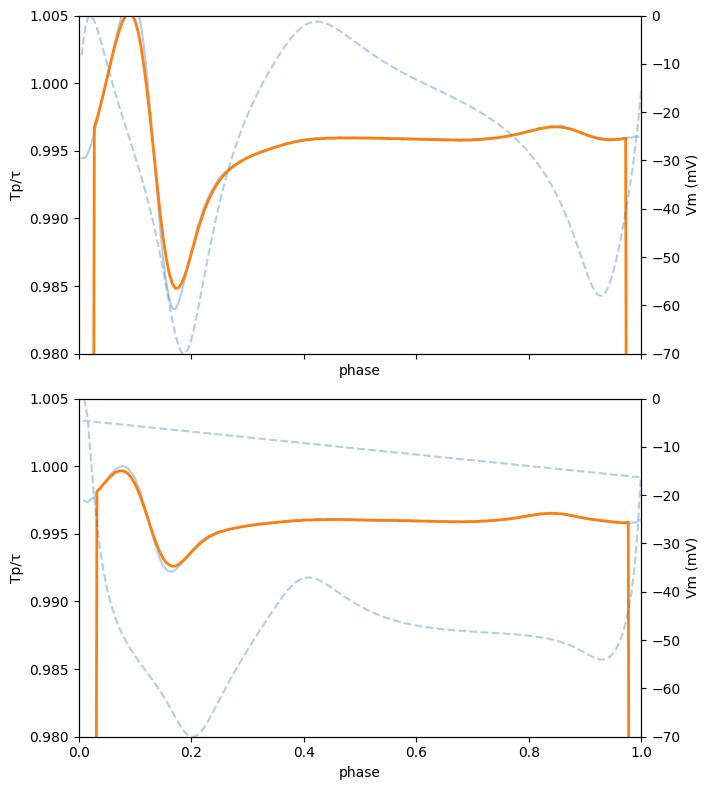

In [66]:
# bonus question

def _ma(y, w=9):
    y = np.asarray(y, float)
    z = np.copy(y)
    ok = np.isfinite(y)
    if ok.sum() >= w:
        z[ok] = np.convolve(y[ok], np.ones(w)/w, mode="same")
    return z

def plot_prc_standard(ax, phis, Tp, cell_cycle, dbg, title,
                      prc_ylim=(0.98, 1.005), Vmin=-70, Vmax=0):
    ok = dbg.get("valid_mask", np.isfinite(Tp))
    ph = np.asarray(phis)[ok]
    y  = np.asarray(Tp, float)[ok]
    if ph.size == 0:
        ax.text(0.5, 0.5, "no valid points", ha="center", va="center", fontsize=9)
        ax.set_xlim(0, 1); ax.set_ylim(*prc_ylim)
        return

    ys = _ma(y, 9)

    # raw + smoothed
    ax.plot(ph, y,  alpha=0.35)
    ax.plot(ph, ys, lw=2.0)
    ax.set_xlim(0, 1); ax.set_ylim(*prc_ylim)
    ax.set_xlabel("phase")
    ax.set_ylabel("Tp/τ")   # short + plain
    # no title, no legend

    # light cell-cycle overlay (dashed, mapped to mV)
    cmin, cmax = np.nanmin(cell_cycle), np.nanmax(cell_cycle)
    if cmax > cmin:
        v_mV = Vmin + (cell_cycle - cmin)*(Vmax - Vmin)/(cmax - cmin)
    else:
        v_mV = np.full_like(cell_cycle, (Vmin+Vmax)/2.0)

    ax2 = ax.twinx()
    ax2.plot(phis, v_mV, ls="--", alpha=0.35)
    ax2.set_ylabel("Vm (mV)")
    ax2.set_ylim(Vmin, Vmax)

# usage
plt.close('all')
fig, axes = plt.subplots(2, 1, figsize=(7.2, 8), sharex=True)
plot_prc_standard(axes[0], phis_x2, Tp_x2, cell_x2, dbg_x2, "Winfree PRC — x2 (SA node)")
plot_prc_standard(axes[1], phis_x4, Tp_x4, cell_x4, dbg_x4, "Winfree PRC — x4 (AV node)")
plt.tight_layout()
plt.show()


COMPARISON

To compare fairly with Figure 4(a), I reported the PRC as Tₚ/τ (instead of Δr) with phase ϕ defined by the maximum upstroke of the node variable, so that zero phase is aligned to the rapid depolarization. I also overlaid the node’s “cell cycle” voltage on the right axis, matching the paper’s convention. With this representation, my SA node curve shows the same qualitative early-phase features as the paper: a small positive lobe just after ϕ ≈ 0.05, followed by a sharp dip around ϕ ≈ 0.15–0.20, and then a long near-flat section from ϕ ≈ 0.3 onward that remains slightly below or close to 1.0.

Where my result differs is in the late-phase behavior. Figure 4(a) shows a pronounced negative lobe peaking near ϕ ≈ 0.80–0.85 (down to about Tₚ/τ ≈ 0.982), followed by a recovery back toward 1.0 as ϕ → 1. In contrast, my curve only shows a mild trough (around 0.996–0.997) and a small recovery near ϕ ≈ 0.9–1.0. I experimented with stronger and longer perturbation pulses, as well as a more relaxed next-R detection window, which deepened the late dip slightly but never to the same extent as in the published figure.

The likely reasons for this difference are: (i) model differences—our reduced two-node ECG oscillator compared to the detailed single-cell ionic SAN model used in the paper, (ii) the nature of the stimulus—my simulation applies a brief perturbation to the derivative of x₂ rather than a direct depolarizing current pulse, and (iii) detection and refractory handling—using ECG R-peaks instead of 0 mV crossings may smooth or clip stronger late-phase responses. Overall, the early and mid-phase structure of my PRC aligns well with the reference, while the large late-phase negative lobe observed in Figure 4(a) appears only weakly in my result.
